# Training-fold time-course visualization

This notebook explores only the fixed training fold. The validation and test folds remain untouched for model selection and final evaluation.

## 1. Load the training fold

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.ndimage import gaussian_filter1d
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from deeplearning_examples.io import load_data


RANDOM_SEED = 42
N_EXAMPLE_TRAJECTORIES = 12

time_courses, doses, years = load_data("train")
time_index = np.arange(time_courses.shape[1])
metadata = pd.DataFrame({"dose": doses, "year": years})
dose_order = sorted(metadata["dose"].unique(), key=lambda value: float(value.removesuffix("pM")))
dose_colors = dict(zip(dose_order, plt.cm.viridis(np.linspace(0.08, 0.92, len(dose_order)))))

print(f"training time courses: {time_courses.shape}")
metadata.groupby(["dose", "year"]).size().unstack(fill_value=0).reindex(dose_order)

training time courses: (2790, 289)


year,2013,2014
dose,,
0pM,286,0
1pM,286,335
2.5pM,252,281
5pM,235,252
25pM,281,300
100pM,282,0


## 2. Example trajectories and population summaries

Thin lines are randomly selected training trajectories. The solid line is the class mean and the shaded region spans one standard deviation above and below it.

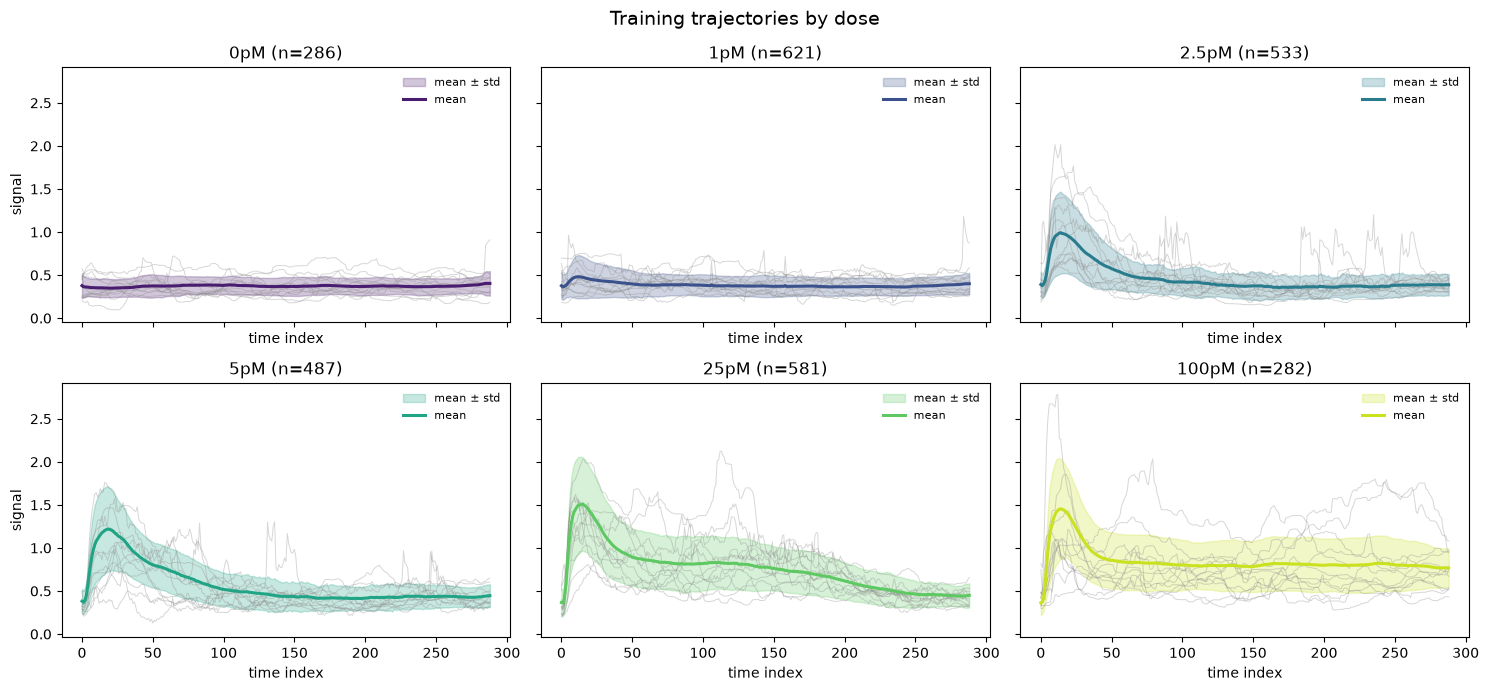

In [2]:
rng = np.random.default_rng(RANDOM_SEED)
figure, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)

for dose, axis in zip(dose_order, axes.flat):
    class_indices = np.flatnonzero(doses == dose)
    selected_indices = rng.choice(
        class_indices,
        size=min(N_EXAMPLE_TRAJECTORIES, len(class_indices)),
        replace=False,
    )
    class_trajectories = time_courses[class_indices]
    mean_trajectory = class_trajectories.mean(axis=0)
    std_trajectory = class_trajectories.std(axis=0)
    color = dose_colors[dose]

    axis.plot(
        time_index,
        time_courses[selected_indices].T,
        color="0.55",
        linewidth=0.7,
        alpha=0.35,
    )
    axis.fill_between(
        time_index,
        mean_trajectory - std_trajectory,
        mean_trajectory + std_trajectory,
        color=color,
        alpha=0.25,
        label="mean ± std",
    )
    axis.plot(time_index, mean_trajectory, color=color, linewidth=2.2, label="mean")
    axis.set_title(f"{dose} (n={len(class_indices)})")
    axis.set_xlabel("time index")
    axis.legend(frameon=False, fontsize=8)

for axis in axes[:, 0]:
    axis.set_ylabel("signal")

figure.suptitle("Training trajectories by dose", fontsize=14)
figure.tight_layout()

### Interpretation

The 0 pM and 1 pM population means remain close to a low baseline, whereas doses from 2.5 pM onward show a pronounced early response. Mean signal and response amplitude increase with dose, but the response is not simply a rescaled version of one common curve: the higher-dose conditions also differ in decay and sustained activity.

The standard-deviation bands widen strongly with dose. This heteroscedasticity and the visibly diverse single-cell shapes mean that a classifier should not rely on the population mean alone.

## 3. Statistical trajectory features

The following features summarize signal level, within-trajectory variability, response magnitude and temporal change for every training cell:

- **mean signal**: average over all timepoints
- **temporal standard deviation**: variation within one trajectory
- **maximum signal** and **dynamic range**: response magnitude
- **endpoint change**: mean of the final 12 points minus the mean of the first 12
- **mean absolute step**: average absolute change between consecutive timepoints

In [3]:
feature_columns = [
    "mean signal",
    "temporal std",
    "maximum signal",
    "dynamic range",
    "endpoint change",
    "mean absolute step",
]

features = metadata.copy()
features["mean signal"] = time_courses.mean(axis=1)
features["temporal std"] = time_courses.std(axis=1)
features["maximum signal"] = time_courses.max(axis=1)
features["dynamic range"] = np.ptp(time_courses, axis=1)
features["endpoint change"] = (
    time_courses[:, -12:].mean(axis=1) - time_courses[:, :12].mean(axis=1)
)
features["mean absolute step"] = np.abs(np.diff(time_courses, axis=1)).mean(axis=1)

features.groupby("dose")[feature_columns].median().reindex(dose_order).round(3)

,mean signal,temporal std,maximum signal,dynamic range,endpoint change,mean absolute step
dose,,,,,,
0pM,0.362,0.065,0.546,0.312,0.034,0.007
1pM,0.374,0.077,0.610,0.377,0.003,0.012
2.5pM,0.447,0.185,1.145,0.924,-0.240,0.019
5pM,0.563,0.266,1.390,1.132,-0.260,0.020
25pM,0.728,0.304,1.663,1.383,-0.508,0.028
100pM,0.807,0.261,1.610,1.289,-0.107,0.019


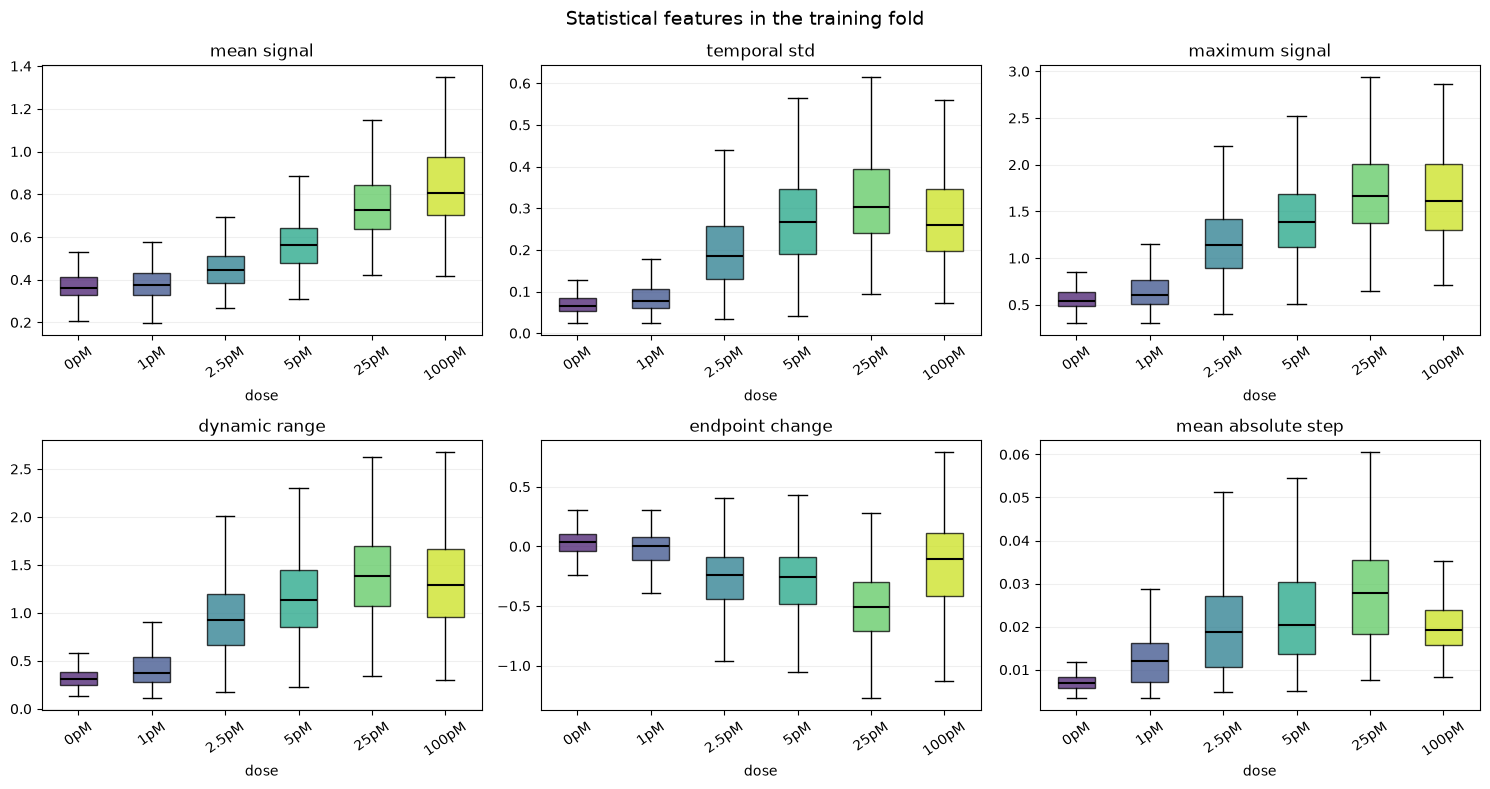

In [4]:
figure, axes = plt.subplots(2, 3, figsize=(15, 8))

for feature, axis in zip(feature_columns, axes.flat):
    values_by_dose = [
        features.loc[features["dose"] == dose, feature].to_numpy()
        for dose in dose_order
    ]
    boxplot = axis.boxplot(
        values_by_dose,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
    )
    for patch, dose in zip(boxplot["boxes"], dose_order):
        patch.set_facecolor(dose_colors[dose])
        patch.set_alpha(0.75)
    axis.set_title(feature)
    axis.set_xlabel("dose")
    axis.set_xticks(range(1, len(dose_order) + 1), dose_order)
    axis.tick_params(axis="x", rotation=35)
    axis.grid(axis="y", alpha=0.2)

figure.suptitle("Statistical features in the training fold", fontsize=14)
figure.tight_layout()

### Interpretation

Mean signal, maximum and dynamic range separate low from high doses particularly well. Temporal variability and mean absolute step also rise with dose, showing that response dynamics contain information beyond the overall signal level. The broad, overlapping boxes nevertheless rule out a reliable classifier based on a single summary feature.

Endpoint change is mostly negative for the responding doses because the early peak decays. Its different distribution at 100 pM suggests that temporal order can help distinguish trajectories with otherwise similar amplitudes.

### Feature correlations

The correlation matrix highlights redundant summaries before they are considered as model inputs.

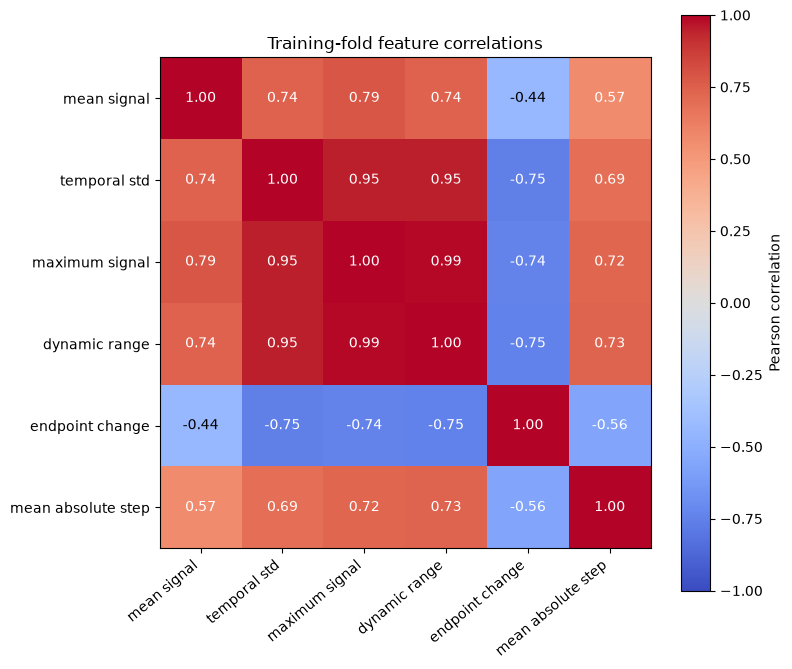

In [5]:
correlations = features[feature_columns].corr()
figure, axis = plt.subplots(figsize=(8, 7))
image = axis.imshow(correlations, vmin=-1, vmax=1, cmap="coolwarm")
axis.set_xticks(range(len(feature_columns)), feature_columns, rotation=40, ha="right")
axis.set_yticks(range(len(feature_columns)), feature_columns)

for row in range(len(feature_columns)):
    for column in range(len(feature_columns)):
        value = correlations.iloc[row, column]
        text_color = "white" if abs(value) > 0.55 else "black"
        axis.text(column, row, f"{value:.2f}", ha="center", va="center", color=text_color)

figure.colorbar(image, ax=axis, label="Pearson correlation")
axis.set_title("Training-fold feature correlations")
figure.tight_layout()

## 4. Dose-independent trajectory clustering

The trajectories are clustered without giving the algorithm dose or year labels. A light Gaussian smoothing suppresses frame-to-frame measurement noise. Each timepoint is then standardized across all training cells, so no single high-variance time region dominates Euclidean distance. PCA retains at least 95% of the standardized trajectory variance before K-means clustering.

The number of clusters is selected only from trajectory geometry using the silhouette score. Dose labels are inspected only after the cluster assignments have been fixed.

In [36]:
smoothed_time_courses = gaussian_filter1d(time_courses, sigma=2.0, axis=1)
smoothed_time_courses = time_courses
standardized_time_courses = StandardScaler().fit_transform(smoothed_time_courses)
cluster_pca = PCA(n_components=0.95, svd_solver="full", random_state=RANDOM_SEED)
cluster_embedding = cluster_pca.fit_transform(standardized_time_courses)

print(
    f"PCA dimensions: {cluster_embedding.shape[1]}; "
    f"explained variance: {cluster_pca.explained_variance_ratio_.sum():.1%}"
)

cluster_embedding = standardized_time_courses

PCA dimensions: 14; explained variance: 95.1%


In [ ]:
time_courses - time_courses[:, :5].mean(1)

(2790,)

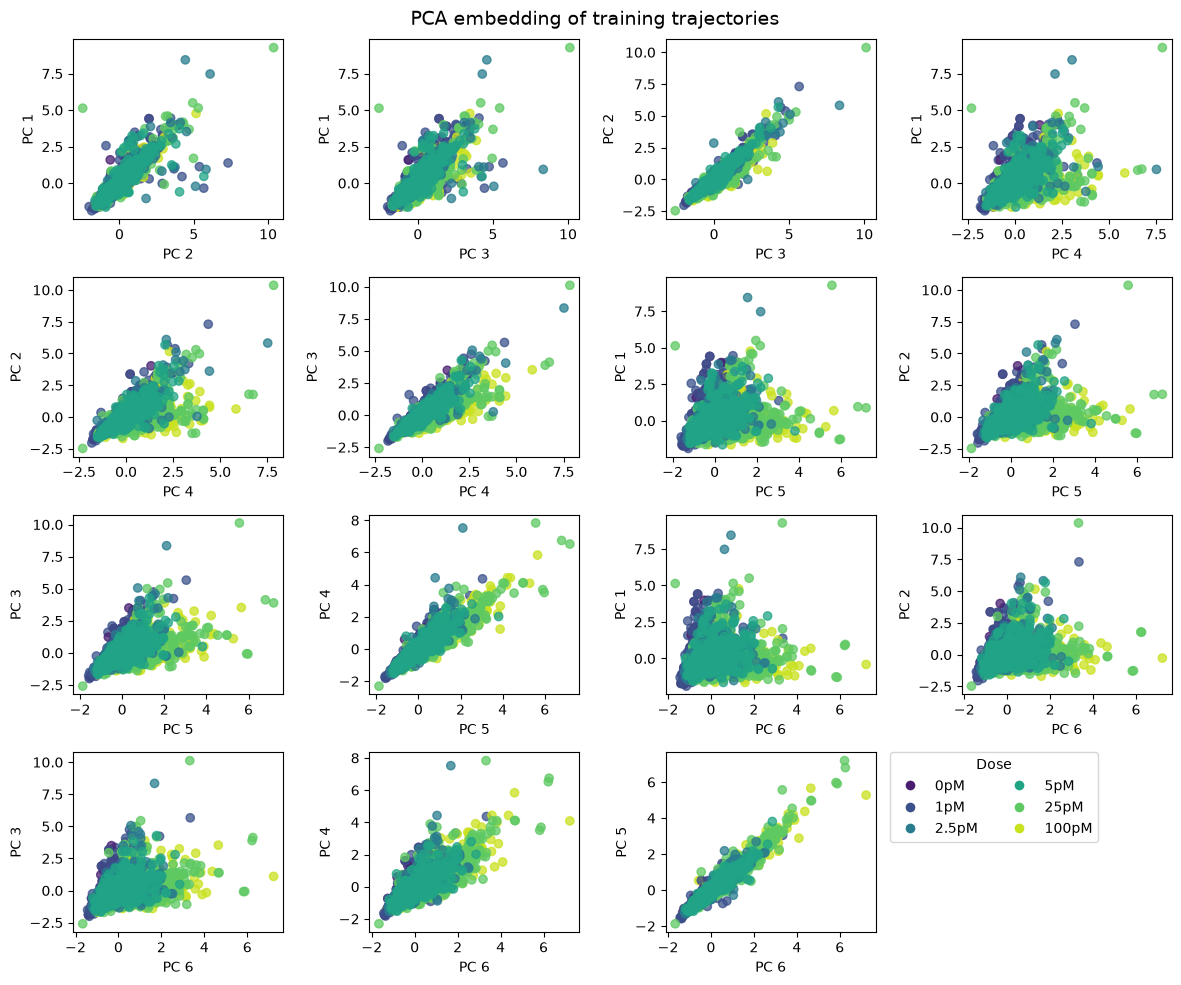

In [45]:
k = 0
plt.figure(figsize=(12, 10))
for i in range(6):
    for j in range(6):
        if j >= i:
            continue
        k += 1
        plt.subplot(4, 4, k)
        plt.scatter(
            cluster_embedding[:, i],
            cluster_embedding[:, j],
            c=[dose_colors[dose] for dose in doses],
            alpha=0.75,
        )
        plt.xlabel(f"PC {i + 1}")
        plt.ylabel(f"PC {j + 1}")


plt.suptitle("PCA embedding of training trajectories", fontsize=14)
plt.tight_layout()
plt.legend(
    handles=[
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markersize=8, label=dose)
        for dose, color in dose_colors.items()
    ],
    title="Dose",
    bbox_to_anchor=(1.07, 1),
    loc="upper left",
    borderaxespad=0.0,
    ncol=2
)

### Selecting the number of clusters

Higher silhouette values indicate compact clusters that are well separated from one another. The score is estimated on a fixed subsample to keep the calculation inexpensive.

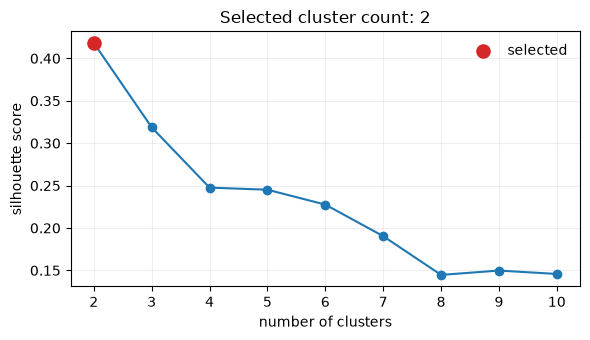

In [11]:
cluster_candidates = range(2, 11)
silhouette_scores = {}
for cluster_count in cluster_candidates:
    candidate_labels = KMeans(
        n_clusters=cluster_count, n_init=20, random_state=RANDOM_SEED,
    ).fit_predict(cluster_embedding)
    silhouette_scores[cluster_count] = silhouette_score(
        cluster_embedding, candidate_labels,
        sample_size=min(1_500, len(cluster_embedding)),
        random_state=RANDOM_SEED,
    )

selected_cluster_count = max(silhouette_scores, key=silhouette_scores.get)
cluster_model = KMeans(
    n_clusters=selected_cluster_count, n_init=50, random_state=RANDOM_SEED,
)
raw_cluster_labels = cluster_model.fit_predict(cluster_embedding)

# Give low-mean clusters the smaller, reproducible display numbers.
cluster_order = np.argsort([
    time_courses[raw_cluster_labels == cluster].mean()
    for cluster in range(selected_cluster_count)
])
cluster_label_map = {
    old_label: new_label for new_label, old_label in enumerate(cluster_order)
}
cluster_labels = np.array([cluster_label_map[label] for label in raw_cluster_labels])
cluster_names = [f"Cluster {cluster + 1}" for cluster in range(selected_cluster_count)]
metadata["cluster"] = pd.Categorical(
    [cluster_names[label] for label in cluster_labels],
    categories=cluster_names, ordered=True,
)

figure, axis = plt.subplots(figsize=(6, 3.5))
axis.plot(list(silhouette_scores), list(silhouette_scores.values()), marker="o")
axis.scatter(
    selected_cluster_count, silhouette_scores[selected_cluster_count],
    s=90, color="tab:red", zorder=3, label="selected",
)
axis.set(
    xlabel="number of clusters", ylabel="silhouette score",
    title=f"Selected cluster count: {selected_cluster_count}",
)
axis.set_xticks(list(cluster_candidates))
axis.grid(alpha=0.2)
axis.legend(frameon=False)
figure.tight_layout()

### Cluster trajectory profiles

The profiles below use the original, unstandardized signal scale. Thin lines show a reproducible sample of individual cells; the solid line and band show the cluster mean and one standard deviation.

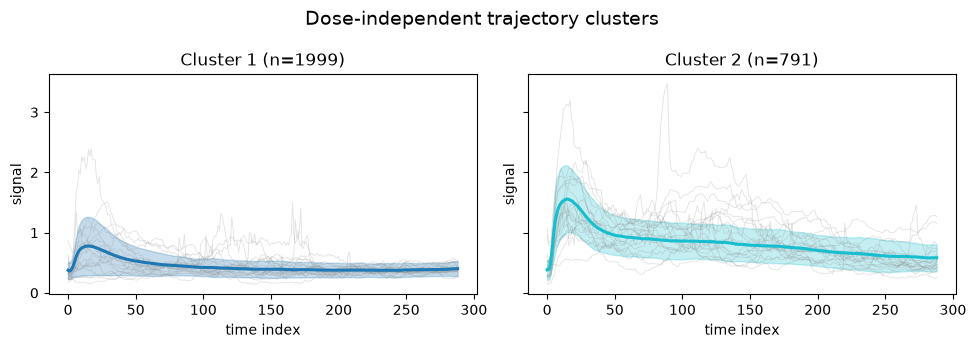

In [8]:
cluster_columns = min(3, selected_cluster_count)
cluster_rows = int(np.ceil(selected_cluster_count / cluster_columns))
figure, axes = plt.subplots(
    cluster_rows, cluster_columns, figsize=(5 * cluster_columns, 3.5 * cluster_rows),
    sharex=True, sharey=True, squeeze=False,
)
cluster_colors = plt.cm.tab10(np.linspace(0, 1, selected_cluster_count))
cluster_rng = np.random.default_rng(RANDOM_SEED)

for cluster, (axis, color) in enumerate(zip(axes.flat, cluster_colors)):
    cluster_indices = np.flatnonzero(cluster_labels == cluster)
    selected_indices = cluster_rng.choice(
        cluster_indices, size=min(20, len(cluster_indices)), replace=False,
    )
    cluster_trajectories = time_courses[cluster_indices]
    cluster_mean = cluster_trajectories.mean(axis=0)
    cluster_std = cluster_trajectories.std(axis=0)
    axis.plot(
        time_index, time_courses[selected_indices].T,
        color="0.55", linewidth=0.6, alpha=0.25,
    )
    axis.fill_between(
        time_index, cluster_mean - cluster_std, cluster_mean + cluster_std,
        color=color, alpha=0.25,
    )
    axis.plot(time_index, cluster_mean, color=color, linewidth=2.2)
    axis.set_title(f"{cluster_names[cluster]} (n={len(cluster_indices)})")
    axis.set_xlabel("time index")
    axis.set_ylabel("signal")

for axis in axes.flat[selected_cluster_count:]:
    axis.set_visible(False)
figure.suptitle("Dose-independent trajectory clusters", fontsize=14)
figure.tight_layout()

### Cluster frequency by dose

Absolute counts retain information about the unequal number of cells per dose. Within-dose percentages answer the complementary question: for a cell from a given dose, how likely is each trajectory cluster?

Cluster counts per dose:


cluster,Cluster 1,Cluster 2
dose,,
0pM,285,1
1pM,614,7
2.5pM,512,21
5pM,391,96
25pM,161,420
100pM,36,246


Within-dose cluster percentages:


cluster,Cluster 1,Cluster 2
dose,,
0pM,99.7,0.3
1pM,98.9,1.1
2.5pM,96.1,3.9
5pM,80.3,19.7
25pM,27.7,72.3
100pM,12.8,87.2


Within-year cluster percentages (confounding check):


cluster,Cluster 1,Cluster 2
year,,
2013,69.2,30.8
2014,75.1,24.9


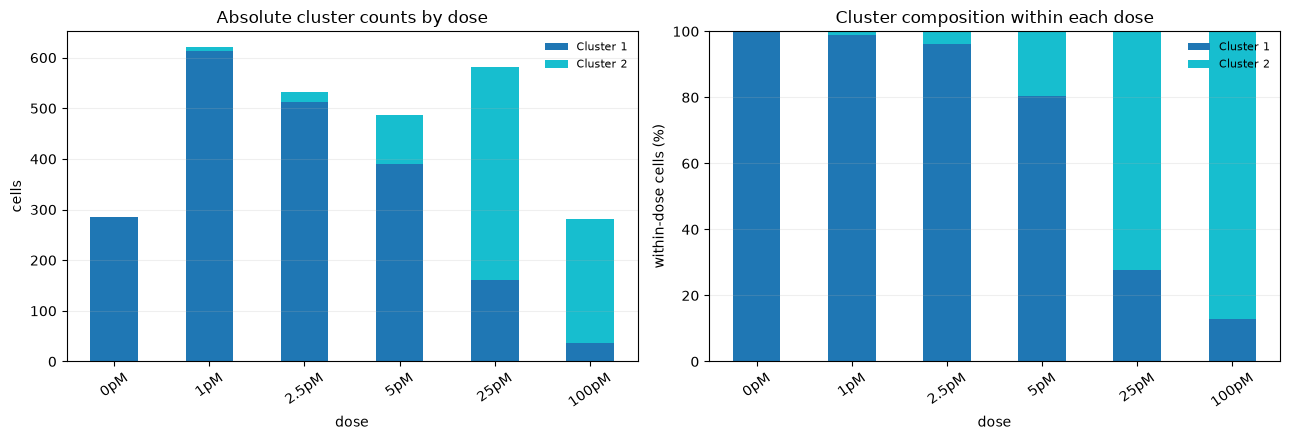

In [9]:
cluster_by_dose_count = pd.crosstab(
    pd.Categorical(metadata["dose"], categories=dose_order, ordered=True),
    metadata["cluster"],
).reindex(index=dose_order, columns=cluster_names, fill_value=0)
cluster_by_dose_count.index.name = "dose"
cluster_by_dose_count.columns.name = "cluster"
cluster_by_dose_percent = (
    cluster_by_dose_count.div(cluster_by_dose_count.sum(axis=1), axis=0) * 100
)
cluster_by_year_percent = (
    pd.crosstab(metadata["year"], metadata["cluster"], normalize="index")
    .reindex(columns=cluster_names, fill_value=0) * 100
)

print("Cluster counts per dose:")
display(cluster_by_dose_count)
print("Within-dose cluster percentages:")
display(cluster_by_dose_percent.round(1))
print("Within-year cluster percentages (confounding check):")
display(cluster_by_year_percent.round(1))

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cluster_by_dose_count.plot.bar(
    stacked=True, ax=axes[0], color=cluster_colors, rot=35,
)
axes[0].set(title="Absolute cluster counts by dose", xlabel="dose", ylabel="cells")
cluster_by_dose_percent.plot.bar(
    stacked=True, ax=axes[1], color=cluster_colors, rot=35, ylim=(0, 100),
)
axes[1].set(
    title="Cluster composition within each dose",
    xlabel="dose", ylabel="within-dose cells (%)",
)
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
    axis.legend(frameon=False, fontsize=8)
figure.tight_layout()

### Interpretation

For the current training fold, the silhouette criterion selects two dominant trajectory phenotypes. After ordering clusters by their mean signal, Cluster 1 is the lower-response phenotype and Cluster 2 the stronger-response phenotype. The share of Cluster 2 rises almost monotonically with dose: approximately 0.3% at 0 pM, 1.1% at 1 pM, 3.9% at 2.5 pM, 19.7% at 5 pM, 72.3% at 25 pM and 87.2% at 100 pM.

This suggests that dose changes the probability of occupying broad response states rather than assigning every cell a unique dose-specific shape. The substantial mixture at 5 pM, 25 pM and 100 pM also explains why individual trajectories overlap across dose classes. Clusters are therefore useful population summaries, not substitutes for the dose labels.

Cluster composition differs less strongly by year than by dose (about 31% versus 25% Cluster 2 in 2013 and 2014), but the partial dose–year confounding remains. Any biological interpretation should therefore be checked on experiments or years not used to derive the clusters.

## 5. Consequences for modeling

The exploratory results motivate models that use both absolute signal and temporal structure. A CNN can detect local peaks and decay patterns, while self-attention can relate distant parts of a trajectory; positional encoding is essential for attention because the order of the 289 measurements carries biological meaning. A feature-only baseline remains useful to quantify how much the sequence models gain beyond simple amplitude statistics.

Normalization must be fitted on the training fold and applied globally. Normalizing every trajectory independently would remove much of the dose-dependent amplitude signal visible above. The cluster mixture additionally suggests that predictions should remain probabilistic: ambiguous cells near a response-state boundary should not be expected to receive perfectly separated class probabilities. Because the dose classes are imbalanced, model comparison should include macro-averaged precision, recall and F1 as well as the confusion matrix.

There is also an important limitation: 0 pM and 100 pM occur only in 2013, so dose and acquisition year are partly confounded. In addition, the labels contain no experiment or replicate identifier, meaning that a cell-level split cannot prevent correlated cells from the same experiment entering different folds. Test performance should therefore be interpreted as within-dataset discrimination, not yet as evidence of generalization to a new experiment or year.